In [1]:

import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plot_utils as plot 
import numpy as np


In [2]:
# base_save_folder = "plots/ukesm/dist_shift/"

# base_path = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/%s/test_runs/wandb_test_%s"
# base_path_2049 = '/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049_equiangular_with_poles_conservative/forecasts/z64_checkpoint_03_last.zarr'

# # nextgems_1990_2020_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/forecasts/z64_checkpoint_03_last.zarr')
# # nextgems_2049_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049_equiangular_with_poles_conservative/forecasts/z64_checkpoint_03_last.zarr', decode_timedelta=True)
# nextgems_1990_2020_equiangular_wp_cons_z128 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/forecasts/z128_checkpoint_03_last.zarr')
# nextgems_2049_equiangular_wp_cons_z128 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049_equiangular_with_poles_conservative/forecasts/z128_checkpoint_03_last.zarr', decode_timedelta=True)

# nextgems_equiangular_wp_cons_truth_1819 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr').sel(time=slice("2018", "2019"))
# nextgems_equiangular_wp_cons_truth_49 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049_equiangular_with_poles_conservative/fields.zarr')

# nextgems_1990_2020_mixed_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_try2/forecasts/z64_checkpoint_03_last.zarr')
# nextgems_2049_mixed_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049/forecasts/z64_checkpoint_03_last.zarr', decode_timedelta=True)

# nextgems_mixed_truth_1819 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_try2/fields.zarr').sel(time=slice("2018", "2019"))
# nextgems_mixed_truth_49 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049/fields.zarr')

In [3]:
base_save_folder = "plots/ukesm/dist_shift/"

ukesm_1990_2020_forecasts_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks_forecasts/z64_graphcast.zarr', decode_timedelta=True).astype(np.float32)
ukesm_2049_forecasts_equiangular_wp_cons_z64 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative_forecasts/z64_graphcast.zarr', decode_timedelta=True).astype(np.float32)

ukesm_historical_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks/fields.zarr').astype(np.float32)
ukesm_future_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative/fields.zarr').astype(np.float32)

In [4]:
def get_temporal_index_in_dataset(timestamp, ds):
    # Suppose your timestamp is
    target_time = timestamp
    
    # get the index object from the DataArray
    time_index = ds.get_index("time")
    
    # find the integer position
    idx = time_index.get_loc(target_time)
    return idx

def get_true_data_matching_forecast_timestamps(ds_forecast, ds_truth, prediction_steps):
    '''
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    '''
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps + 1
    idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth) + prediction_steps + 1
    new_forecast = ds_forecast.copy().isel(prediction_timedelta=prediction_steps)
    new_truth = ds_truth.isel(time=slice(idx_truth_first, idx_truth_last + 1)).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_forecast, new_truth

In [5]:
ds_fore, ds_true = get_true_data_matching_forecast_timestamps(ukesm_1990_2020_forecasts_equiangular_wp_cons_z64, ukesm_historical_truth_equiangular_wp_cons, 10)

InvalidIndexError: 2011-01-01 06:00:00

In [3]:

def wasserstein_1d(a, b):
    return wasserstein_distance(a, b)

def shift_per_gridcell(train, test):
    # Drop time coords (keep only values along "time")
    train_anon = train.copy().chunk(dict(time=-1))
    test_anon = test.copy().chunk(dict(time=-1))
    train_anon = train_anon.assign_coords(time=np.arange(train.sizes["time"]))
    test_anon  = test_anon.assign_coords(time=np.arange(test.sizes["time"]))
    
    return xr.apply_ufunc(
        wasserstein_1d,
        train_anon,
        test_anon,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    
    
def rmse(y, yhat, dim=("time")):
    return np.sqrt(((y - yhat) ** 2).mean(dim))

def weighted_rmse(pred, obs, lat_name="latitude"):
    lats = pred[lat_name].values
    w_lat = np.cos(np.deg2rad(lats))
    
    err2 = (pred - obs) ** 2
    w = np.broadcast_to(w_lat[None, None, :], err2.shape)
    return np.sqrt(np.average(err2, weights=w))


In [4]:
def weighted_wasserstein_1d(a, b, w_a=None, w_b=None):
    """Weighted 1D Wasserstein distance."""
    if w_a is None:
        w_a = np.ones_like(a)
    if w_b is None:
        w_b = np.ones_like(b)
    return wasserstein_distance(a, b, u_weights=w_a/np.sum(w_a), v_weights=w_b/np.sum(w_b))


def shift_global(historical, future, lat_name="latitude"):
    # Flatten time + space
    a = historical.values.flatten()   # historical
    b = future.values.flatten()    # future

    # Build weights (cos(lat) replicated over time and lon)
    lats = historical[lat_name].values
    w_lat = np.cos(np.deg2rad(lats))
    w = np.broadcast_to(w_lat[None, None, :], historical.shape)  # shape = (time, lon, lat)
    w_a = w.flatten()
    w_b = w.flatten()

    # --- Normalize using *historical* weighted mean/std ---
    mean_hist = np.average(a, weights=w_a)
    var_hist  = np.average((a - mean_hist) ** 2, weights=w_a)
    std_hist  = np.sqrt(var_hist)

    a_norm = (a - mean_hist) / std_hist
    b_norm = (b - mean_hist) / std_hist

    return weighted_wasserstein_1d(a_norm, b_norm, w_a, w_b)

In [5]:
def weighted_quantile(values, quantile, sample_weight=None):
    """Compute weighted quantile (0–1)."""
    sorter = np.argsort(values)
    values, weights = values[sorter], sample_weight[sorter]
    cdf = np.cumsum(weights) / np.sum(weights)
    return np.interp(quantile, cdf, values)


def plot_distributions(obs_2019, obs_2049, lat_name="latitude", bins=50, variable_name="Variable", save_to=None):
    """
    Plot weighted histograms of distributions for obs_2019 vs obs_2049.
    
    obs_2019, obs_2049: xarray.DataArray with dims (time, lat, lon)
    """
    # Cos(lat) weights
    lats = obs_2019[lat_name].values
    w_lat = np.cos(np.deg2rad(lats))
    w = np.broadcast_to(w_lat[None, None, :], obs_2019.shape)  # shape (time, lat, lon)

    # Flatten values and weights
    vals19 = obs_2019.values.flatten()
    vals49 = obs_2049.values.flatten()
    w19 = w.flatten()
    w49 = w.flatten()

    # Plot
    plt.figure(figsize=(7,6))
    counts19, bins19, patches19 = plt.hist(vals19, bins=bins, weights=w19/w19.sum(),
                                           alpha=0.5, label="2019", density=True, color="C0")
    counts49, bins49, patches49 = plt.hist(vals49, bins=bins, weights=w49/w49.sum(),
                                           alpha=0.5, label="2049", density=True, color="C1")

    # Weighted means
    mean19 = np.average(vals19, weights=w19)
    mean49 = np.average(vals49, weights=w49)

    # Weighted 95th percentiles
    p95_19 = weighted_quantile(vals19, 0.95, sample_weight=w19)
    p95_49 = weighted_quantile(vals49, 0.95, sample_weight=w49)

    # Add vertical lines
    plt.axvline(mean19, color="C0", linestyle="--", linewidth=2, label="2019 mean")
    plt.axvline(p95_19, color="C0", linestyle=":", linewidth=2, label="2019 95th %")
    plt.axvline(mean49, color="C1", linestyle="--", linewidth=2, label="2049 mean")
    plt.axvline(p95_49, color="C1", linestyle=":", linewidth=2, label="2049 95th %")

    
    plt.xlabel(variable_name)
    plt.ylabel("Probability density")
    plt.title(f"Distribution shift: {variable_name} (2019 vs 2049)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_to:
        plt.savefig(save_to, bbox_inches="tight", dpi=300)
    else:
        plt.show()

In [ ]:
all_performance_1819 = []
all_performance_2049 = []
all_shift_map_2049 = []
all_relative_performance_error = []
all_absolute_performance_error = []
all_relative_performance_percentage = []
all_mean_truth_difference=[]
weighted_wasserstein = []
weighted_rmse_list = []
all_truth_201819 = []
all_truth_2049 = []
all_forecast_201819 = []
all_forecast_2049 = []

mixed = False
historical_year='2019'
future_year='2049'
error_after_hours = 120 # Must be dividable by 6


assert (error_after_hours % 6) == 0 and error_after_hours > 0
error_after_x_steps = int(error_after_hours / 6) - 1

# First prediction is always at 00 or 12 -> if error_after_x_steps is odd, we only look at 00 and 12 time values 
# If not, we only look at 06 and 18 time values
if error_after_x_steps % 2 == 0:
    filter_hours = [6,18]
else: filter_hours = [0,12]

if mixed:
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_try2_z64/plots/"
else:
    # base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/"
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z128/plots/"

for display_name, unit, variable, plevel in plot.KEY_VARIABLES:
    
    
    if mixed:
        truth_1819 = nextgems_mixed_truth_1819.sel(time=historical_year).isel(time=slice(0,-1))[variable]
        truth_49 = nextgems_mixed_truth_49.sel(time=future_year)[variable]
        forecast_1819 = nextgems_1990_2020_mixed_z64.sel(time=historical_year)[variable].sel(time=nextgems_1990_2020_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
        forecast_49 = nextgems_2049_mixed_z64.sel(time=future_year)[variable].sel(time=nextgems_2049_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
    else:
        truth_1819 = nextgems_equiangular_wp_cons_truth_1819.sel(time=historical_year)[variable]
        truth_1819 = truth_1819.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_1819 = truth_1819.sel(time=truth_1819.time.dt.hour.isin(filter_hours))
        truth_49 = nextgems_equiangular_wp_cons_truth_49.sel(time=future_year)[variable]
        truth_49 = truth_49.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_49 = truth_49.sel(time=truth_49.time.dt.hour.isin(filter_hours))
        forecast_1819 = nextgems_1990_2020_equiangular_wp_cons_z128.sel(time=historical_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        forecast_49 = nextgems_2049_equiangular_wp_cons_z128.sel(time=future_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        print(forecast_1819['time'])
        print(truth_1819['time'])
        forecast_1819['time'] = truth_1819['time']
        forecast_49['time'] = truth_49['time']
        
        
    if plevel:
        truth_1819 = truth_1819.sel(level=plevel)
        truth_49 = truth_49.sel(level=plevel)
        forecast_1819 = forecast_1819.sel(level=plevel)
        forecast_49 = forecast_49.sel(level=plevel)
        
    

    all_truth_201819.append(truth_1819)
    all_truth_2049.append(truth_49)
    all_forecast_201819.append(forecast_1819)
    all_forecast_2049.append(forecast_49)
    performance_1819 = rmse(truth_1819, forecast_1819)
    performance_2049 = rmse(truth_49, forecast_49)
    all_relative_performance_percentage.append((performance_2049 - performance_1819) / performance_1819 * 100)
    all_performance_1819.append(performance_1819)
    all_performance_2049.append(performance_2049)
    all_shift_map_2049.append(shift_per_gridcell(truth_1819, truth_49))
    weighted_wasserstein.append(shift_global(truth_1819, truth_49))
    weighted_rmse_1819 = weighted_rmse(truth_1819, forecast_1819)
    weighted_rmse_49 = weighted_rmse(truth_49, forecast_49)
    weighted_rmse_list.append((weighted_rmse_49 - weighted_rmse_1819) / weighted_rmse_1819 * 100)
    all_relative_performance_error.append(performance_2049 / performance_1819)
    all_absolute_performance_error.append(performance_2049 - performance_1819)
    all_mean_truth_difference.append(truth_49.mean('time') - truth_1819.mean('time'))

<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.000000000', ..., '2019-12-20T18:00:00.000000000',
       '2019-12-21T06:00:00.000000000', '2019-12-21T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120
  * time                  (time) datetime64[ns] 6kB 2019-01-01T06:00:00 ... 2...
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-06T12:00:00.000000000', '2019-01-07T00:00:00.000000000',
       '2019-01-07T12:00:00.000000000', ..., '2019-12-26T00:00:00.000000000',
       '2019-12-26T12:00:00.000000000', '2019-12-27T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 2019-01-06T12:00:00 ... 2019-12-27
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.

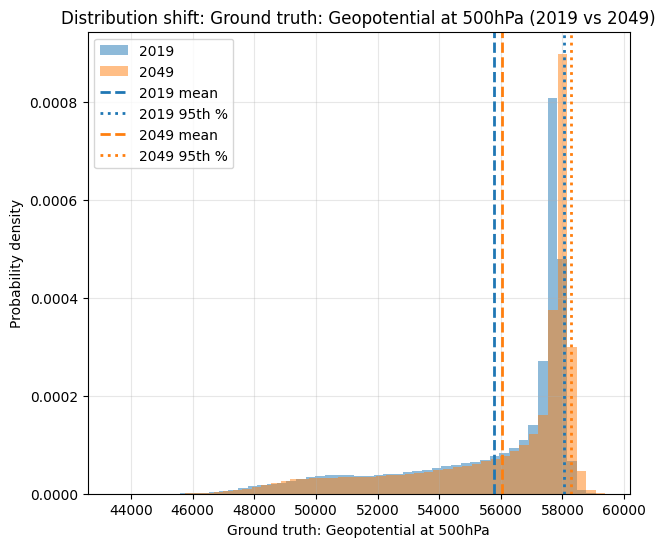

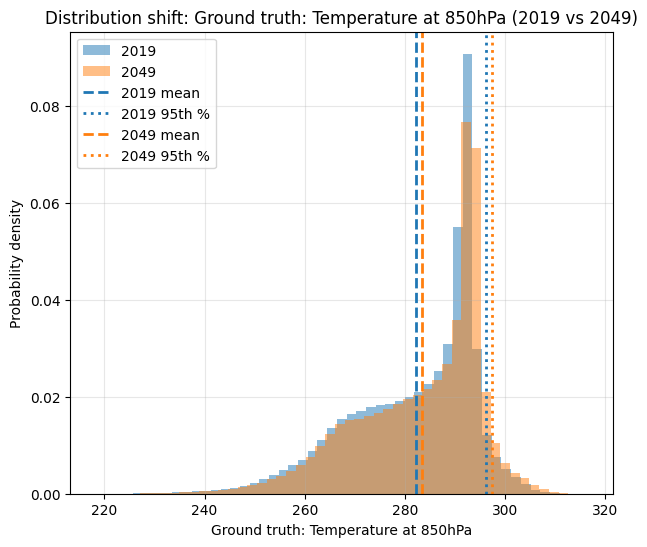

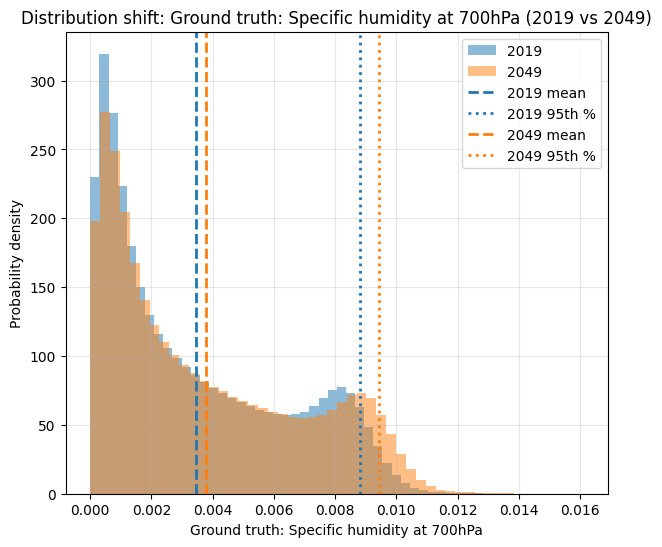

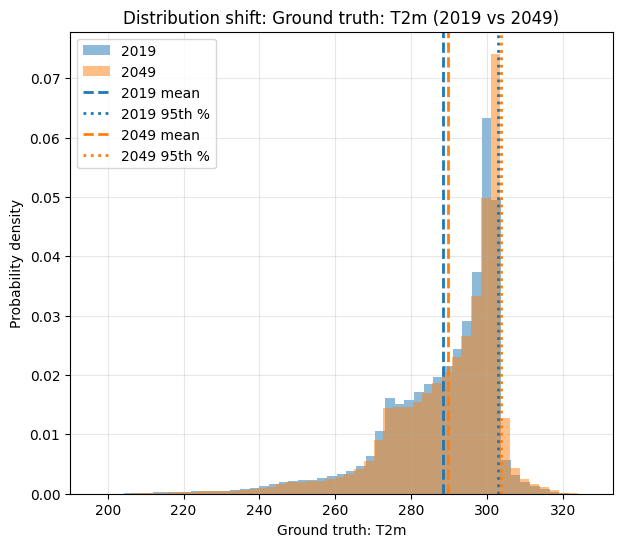

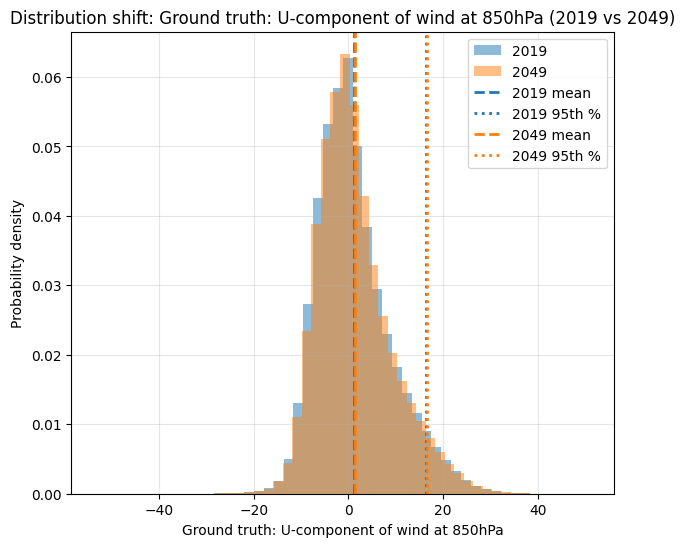

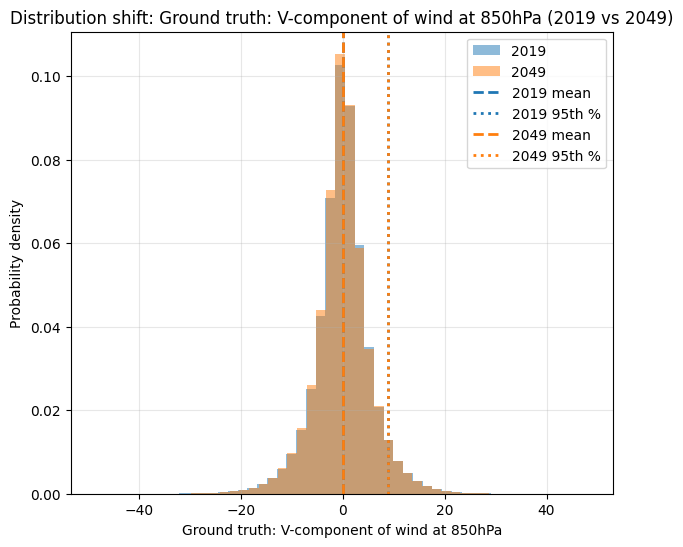

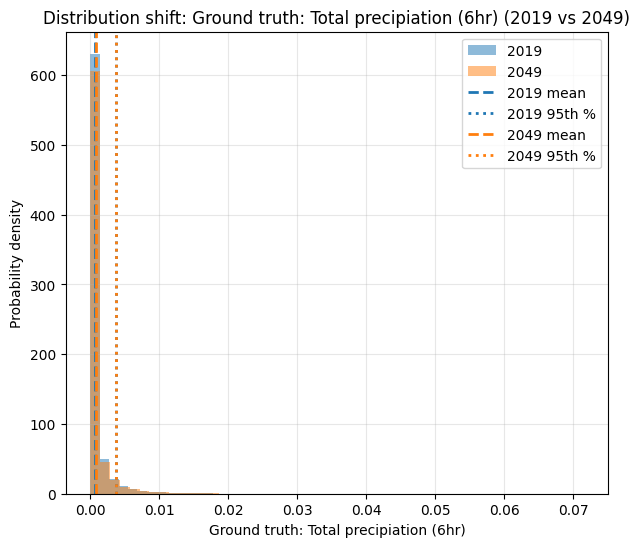

In [15]:
# Zonally weighted
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plot_distributions(all_truth_201819[i], all_truth_2049[i], variable_name='Ground truth: '+ display_name, save_to=base_save_folder + f'truth_distribution_shift/{display_name.replace(" ", "_")}_zonally_weighted.png')

In [16]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_mean_truth_difference[i],
        title=f"Absolute difference in {display_name} (2049 vs 2019)",
        y_label=f"Absolute difference (2049 / 2019) in {unit}",
        #vbounds=(-max_val,max_val),
        base_save_folder=base_save_folder+"zonal_average_shift/",
        save_name=f"zonal_truth_difference_{variable}{plevel_display.replace(' ', '_')}",
        label_below="Value decrease (in 2049)",
        label_above="Value increase (in 2049)",
        centered_around=0,
        color_above='green',
        color_below='red'
    )

In [17]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_relative_performance_percentage[i],
        title=f"Zonal mean of relative performance error after {error_after_x_steps} steps (2049 vs 2019)\n{display_name}",
        y_label="Relative RMSE (2049 - 2019) / 2019 in %",
        centered_around=0,
        base_save_folder=base_save_folder+"zonal_relative_performance/",
        save_name=f"zonal_relative_performance_percentage_{variable}{plevel_display.replace(' ', '_')}_after{error_after_x_steps}steps"
    )


In [27]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, weighted_rmse_list)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, weighted_rmse_list[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(0, max(weighted_wasserstein) * 1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance_.png", dpi=300)
plt.close()

### Local RMSE per Wasserstein distance

Computing the Wasserstein distance between the distribution per gridpoint over 2049 and the global distribution in 2049.
Plot the local RMSE per grid point after x steps onto the local Wasserstein distance.

In [19]:
index = 1

gt = all_truth_2049[index].astype(np.float32).load()  # (time, lon, lat)
sim_sel = all_forecast_2049[index].astype(np.float32).load()   # (time, lon, lat)
relative_rmse_difference = (all_performance_2049[index]-all_performance_1819[index])/all_performance_1819[index]
true_data_mean = all_truth_2049[index].mean(dim='time')
true_data_mean_19 = all_truth_201819[index].mean(dim='time') 

display_name, unit, variable, plevel = plot.KEY_VARIABLES[index]
plevel_display = f' at {plevel}hPa' if plevel else ' at surface'

In [12]:
from joblib import Parallel, delayed
import numpy as np
import xarray as xr
from tqdm import tqdm

gt_vals = gt.values
sim_vals = sim_sel.values

# --- Latitude weights ---
lats = gt["latitude"].values
w_lat = np.cos(np.deg2rad(lats))
w_lat = w_lat / w_lat.mean()

# Broadcast weights to (time, lon, lat)
W = xr.DataArray(
    np.broadcast_to(w_lat[np.newaxis, np.newaxis, :],
                    gt.shape),
    coords=gt.coords, dims=gt.dims
)

# Precompute flattened global distribution
vals_global = gt_vals.flatten()
wg_global   = W.values.flatten()

mask_global = np.isfinite(vals_global)
vals_global = vals_global[mask_global]
wg_global   = wg_global[mask_global]

# Convert coords to plain floats (important for joblib!)
lons = gt.longitude.values.astype(float)
lats = gt.latitude.values.astype(float)
points = [(lon, lat) for lon in lons for lat in lats]
lon_index = {lon: i for i, lon in enumerate(gt.longitude.values)}
lat_index = {lat: j for j, lat in enumerate(gt.latitude.values)}

some_local_gt = gt_vals[:, 0, 0]
w_local = np.ones_like(some_local_gt)

def process_point(lon, lat):
    # Extract raw NumPy arrays (avoids slow .sel each call)
    i, j = lon_index[lon], lat_index[lat]
    local_gt = gt_vals[:, i, j]    
    local_sim = sim_vals[:, i, j]  

    ws = float(weighted_wasserstein_1d(local_gt, vals_global, w_local, wg_global))
    rmse = float(np.sqrt(np.mean((local_sim - local_gt) ** 2)))
    return ws, rmse

# Parallel loop
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_point)(lon, lat) for lon, lat in tqdm(points)
)

# Convert results directly to arrays for plotting
results = np.array(results)   # shape (npoints, 2)
ws_distances = results[:, 0]
rmses = results[:, 1]


100%|██████████| 8192/8192 [07:55<00:00, 17.22it/s]


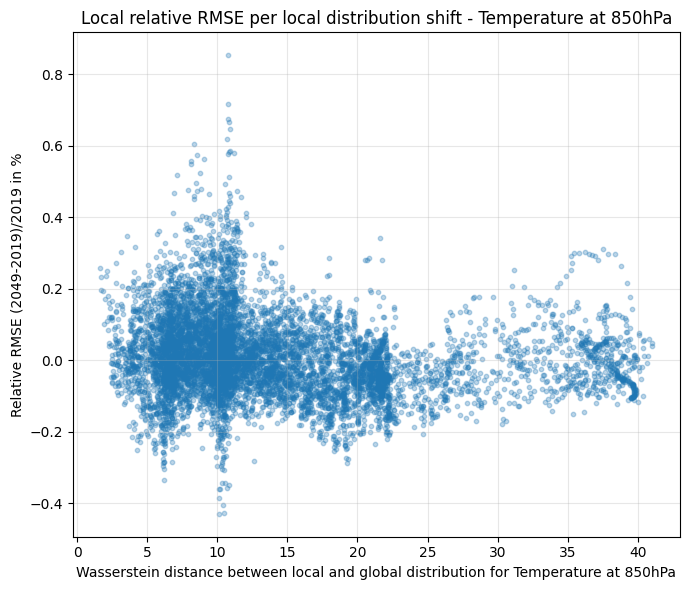

In [13]:
plt.figure(figsize=(7,6))
plt.scatter(ws_distances, relative_rmse_difference, alpha=0.3, s=10)
plt.xlabel(f"Wasserstein distance between local and global distribution for {display_name}")
plt.ylabel("Relative RMSE (2049-2019)/2019 in %")
plt.title(f"Local relative RMSE per local distribution shift - {display_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+variable+f"/rel_rmse_per_local_to_global_wasserstein_point_{variable}{plevel_display.replace(' ', '_')}.png", dpi=300)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from importlib import reload
reload(plot)
import plot_utils as plot 

# Get lon/lat coordinates
lons = gt.longitude.values
lats = gt.latitude.values

# Reshape 1D arrays into 2D grids
n_lon = len(lons)
n_lat = len(lats)

ws_grid = np.reshape(ws_distances, (n_lon, n_lat))   
rmse_grid = np.reshape(rmses, (n_lon, n_lat))       

ws_ds = xr.Dataset(
            {variable: (('longitude','latitude'), ws_grid)},
            coords={
        "latitude": lats,
        "longitude": lons,
    })

# Optional: flip latitude if needed for plotting
if lats[0] > lats[-1]:
    ws_grid = ws_grid[::-1, :]
    rmse_grid = rmse_grid[::-1, :]
    lats = lats[::-1]

plot.plot_double_plot(data_left=ws_ds[variable].T,
                 title_left=f"Distribution shift (Wasserstein, 2049 local to global)\n{display_name}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=true_data_mean.T,
                 title_right=f"Yearly average (2049)\n{display_name}",
                 cbar_label_right=unit,
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/local_to_global_wasserstein_and_yearly_average_{variable}{plevel_display.replace(' ', '_')}")

                
# plot_map(all_truth_2049[0].mean(dim='time'), lons, lats, title="Ground truth 49")
plot.plot_single_plot(data_left=relative_rmse_difference.T,
                 title_left=f"Relative RMSE difference (2049-2019)/2019 after {error_after_x_steps} steps",
                 cbar_label_left="Relative RMSE difference in %",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/relative_rmse_2049_to_2019_after_{error_after_x_steps}steps_{variable}{plevel_display.replace(' ', '_')}")
plot.plot_single_plot(data_left=(true_data_mean - true_data_mean_19).T,
                 title_left=f"Mean value difference (2049-2019)",
                 cbar_label_left=f"Mean difference in {unit}",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/mean_value_difference_2049_to_2019_{variable}{plevel_display.replace(' ', '_')}")


NameError: name 'ws_distances' is not defined

In [21]:
lats = truth_1819['latitude'].values
w_lat = np.cos(np.deg2rad(lats))
print(w_lat)

[6.12323400e-17 4.98458857e-02 9.95678466e-02 1.49042266e-01
 1.98146143e-01 2.46757398e-01 2.94755174e-01 3.42020143e-01
 3.88434796e-01 4.33883739e-01 4.78253979e-01 5.21435203e-01
 5.63320058e-01 6.03804410e-01 6.42787610e-01 6.80172738e-01
 7.15866849e-01 7.49781203e-01 7.81831482e-01 8.11938006e-01
 8.40025923e-01 8.66025404e-01 8.89871809e-01 9.11505852e-01
 9.30873749e-01 9.47927346e-01 9.62624247e-01 9.74927912e-01
 9.84807753e-01 9.92239207e-01 9.97203797e-01 9.99689182e-01
 9.99689182e-01 9.97203797e-01 9.92239207e-01 9.84807753e-01
 9.74927912e-01 9.62624247e-01 9.47927346e-01 9.30873749e-01
 9.11505852e-01 8.89871809e-01 8.66025404e-01 8.40025923e-01
 8.11938006e-01 7.81831482e-01 7.49781203e-01 7.15866849e-01
 6.80172738e-01 6.42787610e-01 6.03804410e-01 5.63320058e-01
 5.21435203e-01 4.78253979e-01 4.33883739e-01 3.88434796e-01
 3.42020143e-01 2.94755174e-01 2.46757398e-01 1.98146143e-01
 1.49042266e-01 9.95678466e-02 4.98458857e-02 6.12323400e-17]


In [22]:
print(all_relative_performance_percentage)

[<xarray.DataArray 'geopotential' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 500
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 850
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'specific_humidity' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtyp

In [23]:
calculated_rmse = [(x.mean(dim="longitude") * w_lat).sum() / w_lat.sum() for x in all_relative_performance_percentage]

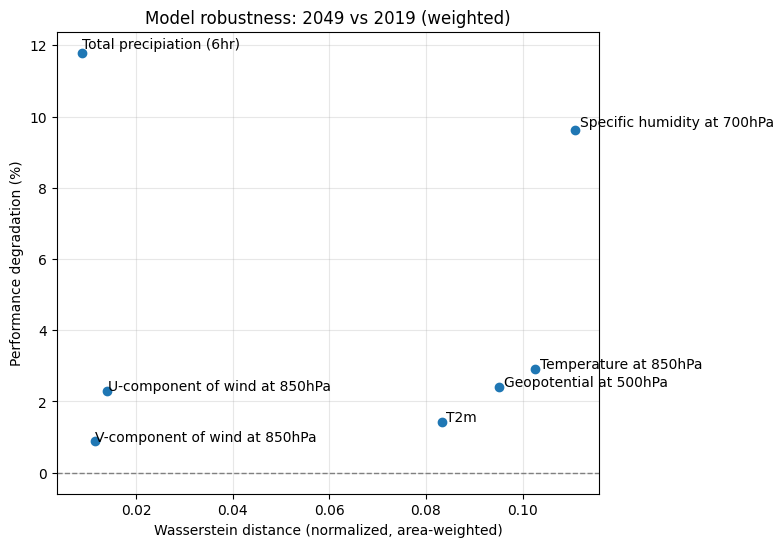

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, calculated_rmse)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, calculated_rmse[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(max(weighted_wasserstein)*1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance.png", dpi=300)

In [9]:

plot.plot_double_plot(data_left=shift_map_2049.T,
                 title_left=f"Distribution shift (Wasserstein, 2049 vs 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=relative_performance_error.T,
                 title_right=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Relative performance degradation",
                 vbounds_right=(0.3, 1.7),
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f'shift_relative_performance_{info_to_save}')

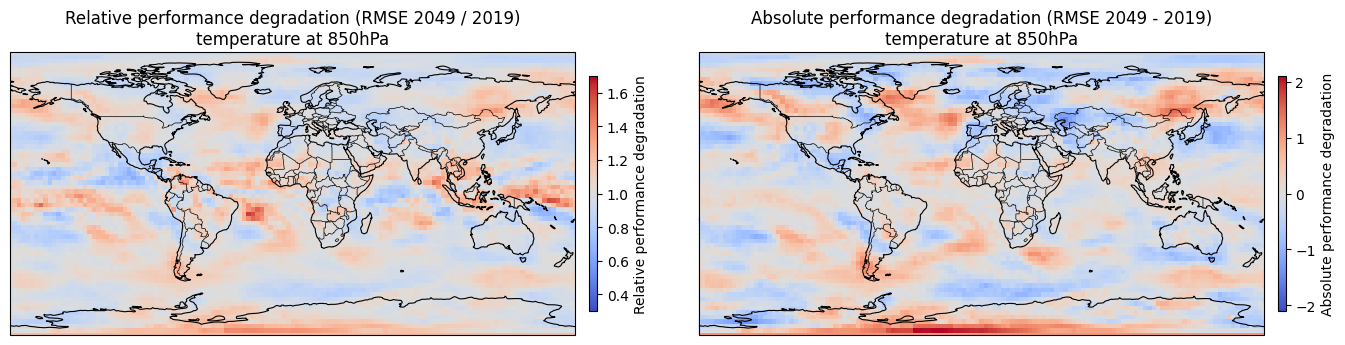

In [ ]:

plot.plot_double_plot(data_left=relative_performance_error.T,
                 title_left=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Relative performance degradation",
                 vbounds_left=(0.3, 1.7),
                 cmap_left="coolwarm",
                 data_right=absolute_performance_error.T,
                 title_right=f"Absolute performance degradation (RMSE 2049 - 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Absolute performance degradation",
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f"absolute_relative_performance_{info_to_save}")

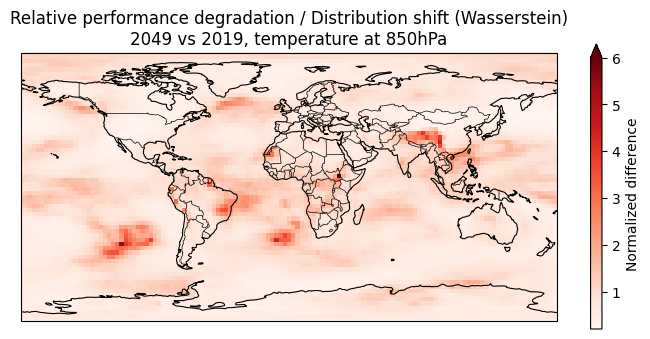

In [62]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 1, figsize=(7,6), subplot_kw={"projection": proj})
(relative_performance_error / shift_map_2049).T.plot(ax=axes, cmap="Reds", transform=proj, vmax=6, cbar_kwargs={"shrink": 0.5, "aspect": 25, "label": "Normalized difference"})
axes.add_feature(cfeature.COASTLINE, linewidth=0.8)
axes.add_feature(cfeature.BORDERS, linewidth=0.5)
axes.set_title(f"Relative performance degradation / Distribution shift (Wasserstein)\n2049 vs 2019, {variable}{f' at {plevel}hPa' if plevel else ''}")

plt.tight_layout()
plt.savefig(base_save_folder+f"normalized_performance_degradation_{info_to_save}.png", dpi=300, bbox_inches='tight')